In [1]:
%cd ..

/Users/v1adych/inno/data-mining/group_project


In [2]:
import polars as pl
import numpy as np
from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance

import matplotlib.pyplot as plt

ASSETS = Path("assets")
ASSETS.mkdir(exist_ok=True, parents=True)

In [3]:
df = pl.read_parquet("data/pr_dataset.parquet")

df.shape, df.select(pl.col("merged").mean().alias("merge_rate"))

((195425, 36),
 shape: (1, 1)
 ┌────────────┐
 │ merge_rate │
 │ ---        │
 │ f64        │
 ╞════════════╡
 │ 0.857383   │
 └────────────┘)

In [4]:
df.select(pl.col("author_association").n_unique().alias("author_association_count"))

author_association_count
u32
1


In [5]:
df.select("author_association")

author_association
str
"""UNKNOWN"""
"""UNKNOWN"""
"""UNKNOWN"""
"""UNKNOWN"""
"""UNKNOWN"""
…
"""UNKNOWN"""
"""UNKNOWN"""
"""UNKNOWN"""


In [6]:
numeric_features = [
    "commits",
    "additions",
    "deletions",
    "changed_files",
    "opened_hour",
    "opened_weekday",
    "opened_on_weekend",
    "draft",

    "repo_events_before_day",
    "repo_pr_events_before_day",
    "repo_issue_comments_before_day",
    "repo_push_events_before_day",
    "repo_actor_days_before_day",

    "actor_events_before_day",
    "actor_repo_days_before_day",
    "actor_pr_events_before_day",
    "actor_issue_comments_before_day",
    "actor_push_events_before_day",
]

target = "merged"

In [7]:
df_model = (
    df
    .with_columns(
        (pl.col("additions") + pl.col("deletions")).alias("total_changed_lines"),

        pl.col("additions").log1p().alias("log_additions"),
        pl.col("deletions").log1p().alias("log_deletions"),
        pl.col("changed_files").log1p().alias("log_changed_files"),
        pl.col("commits").log1p().alias("log_commits"),

        (
            pl.col("repo_pr_events_before_day") /
            (pl.col("repo_events_before_day") + 1)
        ).alias("repo_pr_share_before_day"),

        (
            pl.col("repo_issue_comments_before_day") /
            (pl.col("repo_events_before_day") + 1)
        ).alias("repo_issue_comment_share_before_day"),

        (
            pl.col("actor_pr_events_before_day") /
            (pl.col("actor_events_before_day") + 1)
        ).alias("actor_pr_share_before_day"),
    )
)

numeric_features = numeric_features + [
    "total_changed_lines",
    "log_additions",
    "log_deletions",
    "log_changed_files",
    "log_commits",
    "repo_pr_share_before_day",
    "repo_issue_comment_share_before_day",
    "actor_pr_share_before_day",
]

In [8]:
X = df_model.select(numeric_features).to_pandas()
y = df_model.select(target).to_series().to_numpy()

X.shape, y.mean()

((195425, 26), np.float64(0.8573826276064986))

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y,
)

X_train.shape, X_test.shape, y_train.mean(), y_test.mean()

((146568, 26),
 (48857, 26),
 np.float64(0.857383603515092),
 np.float64(0.8573796999406431))

In [10]:
linear_preprocess = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_features,
        ),
    ]
)

tree_preprocess = ColumnTransformer(
    transformers=[
        (
            "num",
            SimpleImputer(strategy="median"),
            numeric_features,
        ),
    ]
)

In [11]:
models = {
    "dummy_most_frequent": Pipeline(
        steps=[
            ("preprocess", tree_preprocess),
            ("model", DummyClassifier(strategy="most_frequent")),
        ]
    ),

    "logistic_regression": Pipeline(
        steps=[
            ("preprocess", linear_preprocess),
            ("model", LogisticRegression(max_iter=1000, class_weight="balanced")),
        ]
    ),

    "random_forest": Pipeline(
        steps=[
            ("preprocess", tree_preprocess),
            ("model", RandomForestClassifier(
                n_estimators=200,
                max_depth=12,
                min_samples_leaf=50,
                class_weight="balanced_subsample",
                random_state=42,
                n_jobs=-1,
            )),
        ]
    ),

    "hist_gradient_boosting": Pipeline(
        steps=[
            ("preprocess", tree_preprocess),
            ("model", HistGradientBoostingClassifier(
                max_iter=200,
                learning_rate=0.05,
                max_leaf_nodes=31,
                l2_regularization=0.1,
                random_state=42,
            )),
        ]
    ),
}

In [12]:
def precision_at_k(y_true, y_score, k_frac=0.10):
    k = max(1, int(len(y_true) * k_frac))
    order = np.argsort(y_score)[::-1]
    top = order[:k]
    return float(np.mean(y_true[top]))


def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    if hasattr(model[-1], "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    y_pred = model.predict(X_test)

    return {
        "model": name,
        "roc_auc": roc_auc_score(y_test, y_score),
        "pr_auc": average_precision_score(y_test, y_score),
        "f1": f1_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred),
        "precision_at_10pct": precision_at_k(y_test, y_score, 0.10),
        "positive_rate_predicted": float(np.mean(y_pred)),
    }

In [13]:
results = []

for name, model in models.items():
    row = evaluate_model(name, model, X_train, X_test, y_train, y_test)
    results.append(row)
    print(row)

results_df = pl.DataFrame(results).sort("roc_auc", descending=True)
results_df

{'model': 'dummy_most_frequent', 'roc_auc': 0.5, 'pr_auc': 0.8573796999406431, 'f1': 0.9232142463579662, 'precision': 0.8573796999406431, 'recall': 1.0, 'precision_at_10pct': 0.8564994882292732, 'positive_rate_predicted': 1.0}
{'model': 'logistic_regression', 'roc_auc': 0.6546757649289019, 'pr_auc': 0.9119402982562979, 'f1': 0.7827839123075683, 'precision': 0.8950327158787209, 'recall': 0.6955525316908974, 'precision_at_10pct': 0.9527123848515865, 'positive_rate_predicted': 0.6662914219047424}
{'model': 'random_forest', 'roc_auc': 0.7271494066558661, 'pr_auc': 0.9351283874420866, 'f1': 0.8433710279895614, 'precision': 0.9085246534189565, 'recall': 0.7869369046766455, 'precision_at_10pct': 0.9780962128966223, 'positive_rate_predicted': 0.7426366743762408}
{'model': 'hist_gradient_boosting', 'roc_auc': 0.7323952477981623, 'pr_auc': 0.935973067889144, 'f1': 0.9316285089480966, 'precision': 0.8745470160665284, 'recall': 0.9966817064145719, 'precision_at_10pct': 0.9785056294779939, 'positiv

model,roc_auc,pr_auc,f1,precision,recall,precision_at_10pct,positive_rate_predicted
str,f64,f64,f64,f64,f64,f64,f64
"""hist_gradient_boosting""",0.732395,0.935973,0.931629,0.874547,0.996682,0.978506,0.977117
"""random_forest""",0.727149,0.935128,0.843371,0.908525,0.786937,0.978096,0.742637
"""logistic_regression""",0.654676,0.91194,0.782784,0.895033,0.695553,0.952712,0.666291
"""dummy_most_frequent""",0.5,0.85738,0.923214,0.85738,1.0,0.856499,1.0


In [14]:
results_df.write_csv(ASSETS / "model_results.csv")

In [15]:
best_name = results_df["model"][0]
best_model = models[best_name]

best_name

'hist_gradient_boosting'

In [16]:
y_score = best_model.predict_proba(X_test)[:, 1]
y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

confusion_matrix_df = pl.DataFrame({
    "actual": ["not_merged", "not_merged", "merged", "merged"],
    "predicted": ["not_merged", "merged", "not_merged", "merged"],
    "count": [int(cm[0, 0]), int(cm[0, 1]), int(cm[1, 0]), int(cm[1, 1])],
})

confusion_matrix_df.write_csv(ASSETS / "confusion_matrix_best_model.csv")
confusion_matrix_df

actual,predicted,count
str,str,i64
"""not_merged""","""not_merged""",979
"""not_merged""","""merged""",5989
"""merged""","""not_merged""",139
"""merged""","""merged""",41750


In [17]:
report_text = classification_report(y_test, y_pred, digits=4)

with open(ASSETS / "classification_report_best_model.txt", "w") as f:
    f.write(report_text)

print(report_text)

              precision    recall  f1-score   support

           0     0.8757    0.1405    0.2421      6968
           1     0.8745    0.9967    0.9316     41889

    accuracy                         0.8746     48857
   macro avg     0.8751    0.5686    0.5869     48857
weighted avg     0.8747    0.8746    0.8333     48857



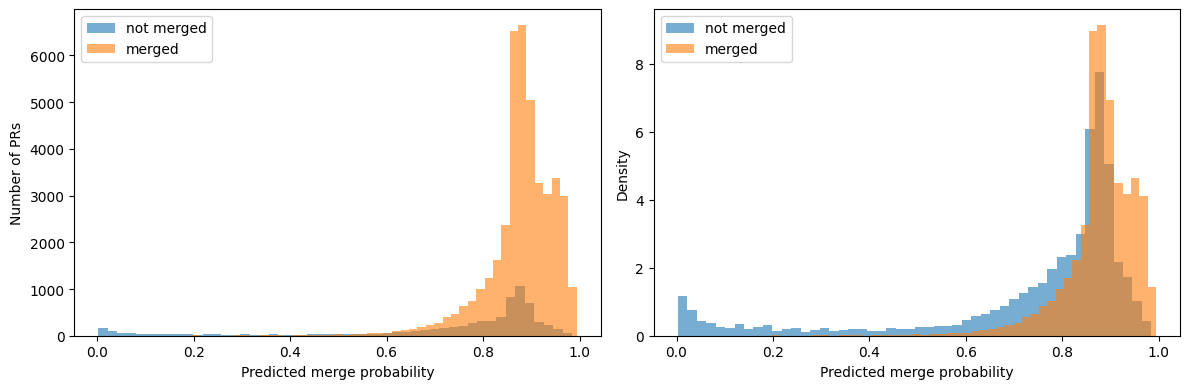

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(y_score[y_test == 0], bins=50, alpha=0.6, label="not merged")
ax1.hist(y_score[y_test == 1], bins=50, alpha=0.6, label="merged")
ax1.set_xlabel("Predicted merge probability")
ax1.set_ylabel("Number of PRs")
ax1.legend()

ax2.hist(y_score[y_test == 0], bins=50, alpha=0.6, density=True, label="not merged")
ax2.hist(y_score[y_test == 1], bins=50, alpha=0.6, density=True, label="merged")
ax2.set_xlabel("Predicted merge probability")
ax2.set_ylabel("Density")
ax2.legend()

plt.tight_layout()
plt.savefig(ASSETS / "predicted_probability_distribution.png", dpi=200)
plt.show()

In [19]:
sample_size = min(20_000, len(X_test))
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(X_test), size=sample_size, replace=False)

X_test_sample = X_test.iloc[sample_idx]
y_test_sample = y_test[sample_idx]

perm = permutation_importance(
    best_model,
    X_test_sample,
    y_test_sample,
    scoring="roc_auc",
    n_repeats=5,
    random_state=42,
    n_jobs=-1,
)

importance_df = (
    pl.DataFrame({
        "feature": X_test.columns.to_list(),
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std,
    })
    .sort("importance_mean", descending=True)
)

importance_df

feature,importance_mean,importance_std
str,f64,f64
"""repo_push_events_before_day""",0.064388,0.002134
"""repo_actor_days_before_day""",0.0579,0.002125
"""actor_push_events_before_day""",0.036786,0.002291
"""repo_issue_comment_share_befor…",0.033,0.000852
"""actor_pr_events_before_day""",0.017058,0.002995
…,…,…
"""draft""",0.0,0.0
"""log_additions""",0.0,0.0
"""log_deletions""",0.0,0.0


In [20]:
importance_df.write_csv(ASSETS / "permutation_importance.csv")

In [21]:
risk_score = 1.0 - y_score
y_unmerged = 1 - y_test

risk_precision_rows = []

for k in [0.01, 0.05, 0.10, 0.20]:
    risk_precision_rows.append({
        "top_fraction": k,
        "risk_precision_at_k": precision_at_k(y_unmerged, risk_score, k),
        "baseline_unmerged_rate": float(y_unmerged.mean()),
    })

risk_precision_df = pl.DataFrame(risk_precision_rows)
risk_precision_df

top_fraction,risk_precision_at_k,baseline_unmerged_rate
f64,f64,f64
0.01,0.993852,0.14262
0.05,0.625717,0.14262
0.1,0.458137,0.14262
0.2,0.332515,0.14262


In [22]:
risk_precision_df.write_csv(ASSETS / "risk_precision_at_k.csv")

In [23]:
rows = []

for threshold in np.linspace(0.1, 0.9, 17):
    pred_unmerged = (risk_score >= threshold).astype(int)

    rows.append({
        "risk_threshold": threshold,
        "flagged_share": pred_unmerged.mean(),
        "precision_unmerged": precision_score(y_unmerged, pred_unmerged, zero_division=0),
        "recall_unmerged": recall_score(y_unmerged, pred_unmerged, zero_division=0),
        "f1_unmerged": f1_score(y_unmerged, pred_unmerged, zero_division=0),
    })

threshold_df = pl.DataFrame(rows)
threshold_df

risk_threshold,flagged_share,precision_unmerged,recall_unmerged,f1_unmerged
f64,f64,f64,f64,f64
0.1,0.665882,0.187625,0.876005,0.309055
0.15,0.261662,0.29138,0.534587,0.377177
0.2,0.150132,0.382686,0.402842,0.392505
0.25,0.091532,0.479875,0.307979,0.375175
0.3,0.059439,0.583333,0.243111,0.343193
…,…,…,…,…
0.7,0.015187,0.960916,0.102325,0.184955
0.75,0.013795,0.974777,0.094288,0.171945
0.8,0.012342,0.986733,0.08539,0.157179


In [24]:
threshold_df.write_csv(ASSETS / "risk_threshold_analysis.csv")